Descripción...
<br>
- Load hit & event-level dataframe.
- Check minimum Q.
- Tag by particle and detector region.
- Trigger02 efficiency cut.
- $nS2=1$ for fiducial events.
- Update summary.

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis/')

from libs import bckg_functions as bf
from libs import crudo
from libs import fit_functions as ff
from libs import plotting_tools as pt

import argparse
import csv
import glob
from invisible_cities.reco.corrections import read_maps, apply_all_correction
from invisible_cities.types.symbols import NormStrategy
from invisible_cities.core.core_functions import in_range
from joblib import Parallel, delayed 
import numpy as np
import os
import pandas as pd
import scipy
from scipy.interpolate import interp1d
from scipy.interpolate import griddata
from scipy.spatial.distance import cdist
from sklearn.neighbors import BallTree
from sklearn.neighbors import NearestNeighbors
from sklearn.exceptions import NotFittedError
from typing import List, Callable, Tuple
from   iminuit      import Minuit
from   iminuit.cost import LeastSquares
import matplotlib.pyplot as plt 

# Styling Plot
pt.ccortesp_plot_style()

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Preliminary

In [2]:
# --------------------------------------------
# 1. DIRECTORIES, PATHS, KEYS AND FILENAMES
# --------------------------------------------
# FILENAME TAG
VERSION_TAG = 'rescale_p1'

# DIRECTORIES, PATHS & FILES
DATA_DIR   = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Sophronia/Low_background/'
ICAROS_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Icaros/Low_background/'
PROCESSED_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/runs/'

RUNS_INFO_PATH = os.path.join('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/utilities/runs_information.csv')

SUMMARY_FILENAME = 'summary_' + VERSION_TAG +'.csv'     # Choose your name
SUMMARY_PATH = os.path.join('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/', SUMMARY_FILENAME)

# KEYS
DORO_KEY = 'DST/Events'
SOPH_KEY = 'RECO/Events'
EVT_KEY  = 'PROCESSED/Events'

# COLUMNS TO USE
DORO_COLUMNS = ['event', 'time', 'nS1', 'nS2', 'S1h', 'S1e', 'S2e', 'DT', 'X', 'Y', 'Z']
SOPH_COLUMNS = ['event', 'time', 'npeak', 'X', 'Y', 'Z', 'Q', 'E']
FINAL_SOPH_COLUMNS = ['event', 'time', 'npeak', 'X', 'Y', 'DT', 'Z', 'E_hit_pe']

# CUTFLOWS
CUT_NAMES = ['Reconstructed', 'Z_Positive', 'S1_Cut', 'Clean_Hits']

# --------------------------------
# 2. ALPHA/ELECTRON DISCRIMINATION
# --------------------------------
S1_ENERGY_THRESHOLD = 900     # in [PE]
SIZE_THRESHOLD = 2e3          # in [# of hits]

# -------------------
# 3. DETECTOR REGIONS
# -------------------
# Geometric boundaries for event classification.
Z_LOW = 40          # in [mm]
Z_UP  = 1147        # in [mm]
R_UP  = 451.65      # in [mm]

# --------------------------------
# 4. SELECTION
# --------------------------------
# --- High Energy Scale Correction ---
M_HE_SCALE = 4.80e-06
B_HE_SCALE = 0.0094

# --- Trigger 2 Efficiency Cut ---
# Events with event-level energy below this are removed to account for trigger efficiency.
TRG2_THRESHOLD = 0.5   # in [MeV]

## Runs & Summary Information

In [3]:
# ----- Load Dataframes ----- #
RUNS_INFO_DF = pd.read_csv(RUNS_INFO_PATH)
RUNS_INFO_DF.columns = RUNS_INFO_DF.columns.str.strip()
RUNS_INFO_DF

,run_number,duration,OK,LOST,period,condition
0,15062,84783,69564,1339,1,castle_open
1,15063,79120,65052,1241,1,castle_open
2,15076,69316,56775,1080,1,castle_open
3,15288,87256,30201,8397,1,castle_pclosed_RAS
4,15289,82152,28180,7884,1,castle_pclosed_RAS
...,...,...,...,...,...,...
106,15733,86919,30475,10027,2,castle_closed_RAS
107,15734,85790,29837,9598,2,castle_closed_RAS
108,15735,87451,30547,9958,2,castle_closed_RAS
109,15736,93376,32622,10506,2,castle_closed_RAS


In [4]:
SUMMARY_DF = pd.read_csv(SUMMARY_PATH)
SUMMARY_DF.drop(columns=['Unnamed: 0'], inplace=True)
SUMMARY_DF.columns = SUMMARY_DF.columns.str.strip()
SUMMARY_DF.sort_values(by='Run_ID', inplace=True)
SUMMARY_DF

,Run_ID,Duration,Date_CV,Date_Err,OK,LOST,Reconstructed,Z_Positive,S1_Cut,Clean_Hits,Trg2_Cut,nElectrons,S2_Cut,nElectron_Fiducial
0,15299,60204,1.747095e+09,146.9611,18014,8929,17411,14809,11554,11553,10360.0,NaN,1514.0,248.0
1,15318,86706,1.747194e+09,172.3596,28735,1011,28043,24307,19081,19074,17006.0,NaN,2701.0,411.0
2,15319,85823,1.747281e+09,174.1556,27973,1008,27274,23734,18553,18544,16449.0,NaN,2480.0,370.0
3,15330,86462,1.747704e+09,171.3388,28157,1043,27508,23924,18485,18474,16407.0,NaN,2389.0,371.0
4,15331,85389,1.747791e+09,172.0570,27390,9966,26800,23300,18121,18115,16065.0,NaN,2281.0,349.0
5,15332,67758,1.747868e+09,154.4476,22010,8142,21445,18624,14434,14424,12781.0,NaN,1878.0,278.0
6,15462,39365,1.747948e+09,115.9820,12847,4532,12533,10878,8534,8532,7567.0,NaN,1061.0,139.0
7,15472,86563,1.748048e+09,175.7367,28505,1001,27372,23881,18707,18699,16482.0,NaN,2508.0,356.0
8,15478,86835,1.748210e+09,174.0899,28702,9999,27808,24299,18935,18924,16691.0,NaN,2650.0,399.0
9,15479,86876,1.748297e+09,174.5319,28713,1003,27966,24290,19014,19008,16746.0,NaN,2520.0,404.0


#### Which runs will you analyze?

A veces querré analizar por _data period_, a veces por _detector condition_ o a veces todo junto.

In [5]:
# ----- Configuration ----- #
DATA_PERIOD = 1                          # Options: None, 1, 2
DETECTOR_CONDITION = 'castle_pclosed'        # Options: None, 'castle_open', 'castle_closed', 'castle_closed_RAS', 'castle_pclosed', 'castle_pclosed_RAS'

In [6]:
selection_mask = pd.Series(True, index=RUNS_INFO_DF.index)

runs_in_summary = SUMMARY_DF['Run_ID'].unique()
print(f"→ Must be one of the {len(runs_in_summary)} runs in the summary.")
selection_mask &= RUNS_INFO_DF['run_number'].isin(runs_in_summary)

if DATA_PERIOD is not None:
    print(f"→ Period == {DATA_PERIOD}")
    # The '&=' operator is a shortcut for 'selection_mask = selection_mask & ...'
    selection_mask &= (RUNS_INFO_DF['period'] == DATA_PERIOD)

if DETECTOR_CONDITION is not None:
    print(f"→ Condition == '{DETECTOR_CONDITION}'")
    selection_mask &= (RUNS_INFO_DF['condition'] == DETECTOR_CONDITION)

RUNS_TO_ANALYZE = RUNS_INFO_DF.loc[selection_mask, 'run_number'].values
print(f"\nSelected {len(RUNS_TO_ANALYZE)} runs for analysis:\n{RUNS_TO_ANALYZE}")

EVT_COUNT_PER_RUN = {run: {'Trg2_Cut': 0, 'nElectrons': 0, 'S2_Cut': 0, 'nElectron_Fiducial': 0} for run in RUNS_TO_ANALYZE}
print(f"\nDictionary for new event counts initialized.")

→ Must be one of the 45 runs in the summary.
→ Period == 1
→ Condition == 'castle_pclosed'

Selected 16 runs for analysis:
[15299 15318 15319 15330 15331 15332 15462 15472 15478 15479 15484 15485
 15486 15487 15488 15489]

Dictionary for new event counts initialized.


# Tagging & Analysis Workflow

## Testing Zone

In [18]:
# 
id_test = np.random.choice(RUNS_TO_ANALYZE)
print(f"\nRandomly selected run for testing: {id_test}")
test_path = os.path.join(PROCESSED_DIR, f'processed_run_{id_test}_{VERSION_TAG}.h5')

test_evt_df = pd.read_hdf(test_path, key='Events')
test_hit_df = pd.read_hdf(test_path, key='Hits')


Randomly selected run for testing: 15478


In [19]:
test_evt_df = bf.tag_particles(test_evt_df, size_threshold=SIZE_THRESHOLD, s1_energy_threshold=S1_ENERGY_THRESHOLD)
test_evt_df = bf.tag_event_by_detector_region(test_evt_df, z_cut_low=Z_LOW, z_cut_high=Z_UP, r_cut_high=R_UP)

In [17]:
test_evt_df

,event,npeak,E_peak_pe,n_hits_peak,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,E_evt_pe,n_hits,time,nS1,nS2,S1e_max,S1e_corr_max,n_hits_original,particle,region
0,4628,26,6.211074e+04,98,-153.110198,19.840670,73.018242,71.533986,80.608052,209.564134,6.211074e+04,98,1.748788e+09,0,1,NaN,NaN,153,electron,anode
1,5482,0,1.209979e+06,5076,-67.095918,-38.794020,1184.013878,1167.466713,1204.834172,484.169202,1.209979e+06,5076,1.748788e+09,1,1,1449.423706,1451.344759,5661,alpha,cathode
2,6238,30,1.965855e+05,277,-50.494514,-456.555399,536.076540,524.236494,547.441416,486.766639,1.965855e+05,277,1.748788e+09,1,1,1213.523926,1666.111703,364,alpha,tube
3,7022,23,1.753811e+05,329,-326.391442,310.283331,492.943935,482.456886,505.733927,496.192600,1.753811e+05,329,1.748788e+09,1,1,993.024475,1397.533833,401,alpha,tube
4,8933,18,2.050311e+05,409,-427.798442,123.748326,1053.860957,1039.576138,1069.982618,494.230529,2.050311e+05,409,1.748788e+09,1,1,1335.711914,1414.022632,477,alpha,tube
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14392,2233595,0,1.121054e+06,4552,51.373101,-72.495061,1185.547051,1167.524451,1204.924024,479.102323,1.121054e+06,4552,1.748848e+09,1,1,1596.545532,1598.026012,5169,alpha,cathode
14393,2233679,0,5.960069e+03,29,-114.567882,-37.525108,1180.815886,548.380482,1203.510289,475.117902,1.096867e+06,4322,1.748848e+09,1,2,1483.874146,2018.013884,4967,alpha,cathode
14394,2233679,1,1.090907e+06,4293,-114.567882,-37.525108,1180.815886,548.380482,1203.510289,475.117902,1.096867e+06,4322,1.748848e+09,1,2,1483.874146,2018.013884,4967,alpha,cathode
14395,2234169,35,1.417215e+05,184,133.749626,-449.257828,93.601737,88.628765,108.509168,494.657494,1.417215e+05,184,1.748848e+09,1,1,1218.611694,2243.315063,273,alpha,tube


In [20]:
# ----- Trg2 Efficiency Cut ----- #
# Convert from [pe] to [MeV] using HE scale
test_evt_df = bf.energy_pe_to_mev(test_evt_df, slope=M_HE_SCALE, intercept=B_HE_SCALE, input_column='E_evt_pe', output_column='E_evt_mev')
test_evt_df = test_evt_df[test_evt_df['E_evt_mev'] >= TRG2_THRESHOLD].copy()
print(f"→ After Trg2 cut: {test_evt_df['event'].nunique()} events remain.")

# ----- Inclusive Electrons ----- #
test_evt_electrons = test_evt_df[test_evt_df['particle'] == 'electron'].copy()
print(f"→ After selecting electrons: {test_evt_electrons['event'].nunique()} events remain.")

# ----- Fiducial Electrons ----- #
# nS2 = 1
test_evt_fiducial = test_evt_electrons[test_evt_electrons['nS2'] == 1].copy()
print(f"→ After nS2 = 1 cut: {test_evt_fiducial['event'].nunique()} events remain.")
# Fiducial region
test_evt_fiducial = test_evt_fiducial[test_evt_fiducial['region'] == 'fiducial'].copy()
print(f"→ After fiducial region cut: {test_evt_fiducial['event'].nunique()} events remain.")

→ After Trg2 cut: 16691 events remain.
→ After selecting electrons: 3101 events remain.
→ After nS2 = 1 cut: 2650 events remain.
→ After fiducial region cut: 399 events remain.


In [43]:
test_evt_electrons

,event,npeak,E_peak_pe,n_hits_peak,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,...,n_hits,time,nS1,nS2,S1e_max,S1e_corr_max,n_hits_original,particle,region,E_evt_mev
9,6392,35,128124.765330,240,-240.083611,-322.812612,20.692007,7.776566,31.303052,482.559075,...,240,1.748167e+09,0,1,NaN,NaN,302,electron,anode,0.624399
26,27581,0,223367.535161,821,-98.723988,-215.684806,1211.355128,1211.355128,1211.355128,472.957462,...,821,1.748167e+09,0,1,NaN,NaN,1819,electron,anode,1.081564
29,34021,31,127066.028723,405,-419.641762,14.069313,1067.648462,1047.347406,1084.909923,482.833119,...,405,1.748167e+09,1,1,141.418488,148.676497,449,electron,tube,0.619317
33,41819,9,160368.864931,383,-105.480686,-142.508792,31.737220,1.445415,58.900337,266.382697,...,383,1.748168e+09,0,1,NaN,NaN,461,electron,anode,0.779171
34,42043,30,118524.347031,344,186.489878,-400.230084,518.369649,504.601859,542.098419,489.985317,...,344,1.748168e+09,1,1,147.756271,205.666129,387,electron,tube,0.578317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20562,3438449,29,110998.762617,186,-27.029865,-267.396488,19.197552,8.972429,24.554971,357.037591,...,186,1.748253e+09,0,1,NaN,NaN,288,electron,anode,0.542194
20563,3439380,15,226816.643935,245,449.935599,116.005666,116.165143,116.150794,117.640433,504.989704,...,245,1.748253e+09,0,2,NaN,NaN,721,electron,anode,1.098120
20576,3451245,14,144443.404790,542,309.539399,-158.024727,1160.050974,1136.561776,1191.434024,411.096815,...,542,1.748253e+09,1,1,172.471008,174.944056,589,electron,cathode,0.702728
20577,3453688,34,117090.319241,296,92.055549,-82.292804,253.528201,241.455235,268.151622,196.212694,...,296,1.748253e+09,1,1,100.807465,165.560794,333,electron,fiducial,0.571434


In [21]:
test_evt_fiducial

,event,npeak,E_peak_pe,n_hits_peak,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,...,n_hits,time,nS1,nS2,S1e_max,S1e_corr_max,n_hits_original,particle,region,E_evt_mev
39,44241,1,246238.172285,584,-98.458726,-177.141520,161.012360,129.572999,225.560211,286.228547,...,584,1.748168e+09,1,1,181.322556,318.186437,685,electron,fiducial,1.191343
50,67488,18,125525.887763,276,-107.947636,184.921162,78.853740,67.533253,94.400477,292.347073,...,276,1.748168e+09,1,1,91.916267,169.905363,331,electron,fiducial,0.611924
127,166412,13,132494.037953,367,-304.131302,-103.229410,840.195104,827.041854,857.586734,394.051458,...,367,1.748171e+09,1,1,137.732056,161.184375,466,electron,fiducial,0.645371
158,209217,27,105346.689823,231,-134.175984,26.447092,97.977826,89.373530,108.867386,213.427813,...,231,1.748172e+09,1,1,51.406330,94.155399,290,electron,fiducial,0.515064
238,289640,16,177585.658871,376,-109.259386,251.372744,89.210200,67.022903,103.684198,341.699482,...,376,1.748174e+09,1,1,103.871117,191.341768,460,electron,fiducial,0.861811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20454,3325798,36,102766.158940,150,-23.942153,-231.211891,56.306603,48.050534,63.685301,316.778892,...,150,1.748250e+09,1,1,88.640709,167.397149,233,electron,fiducial,0.502678
20493,3355268,27,139956.398767,439,37.931466,52.518263,824.208611,785.933269,850.938776,150.720142,...,439,1.748251e+09,1,1,153.955460,180.214733,482,electron,fiducial,0.681191
20520,3394888,9,209841.461993,824,-136.103435,-117.245660,1099.257335,1070.813559,1125.615958,278.812538,...,824,1.748252e+09,1,1,299.396606,309.935833,899,electron,fiducial,1.016639
20528,3399984,1,207085.709269,533,-25.247394,39.384801,264.133123,237.044600,298.506094,114.122177,...,533,1.748252e+09,1,1,170.255600,275.693283,590,electron,fiducial,1.003411


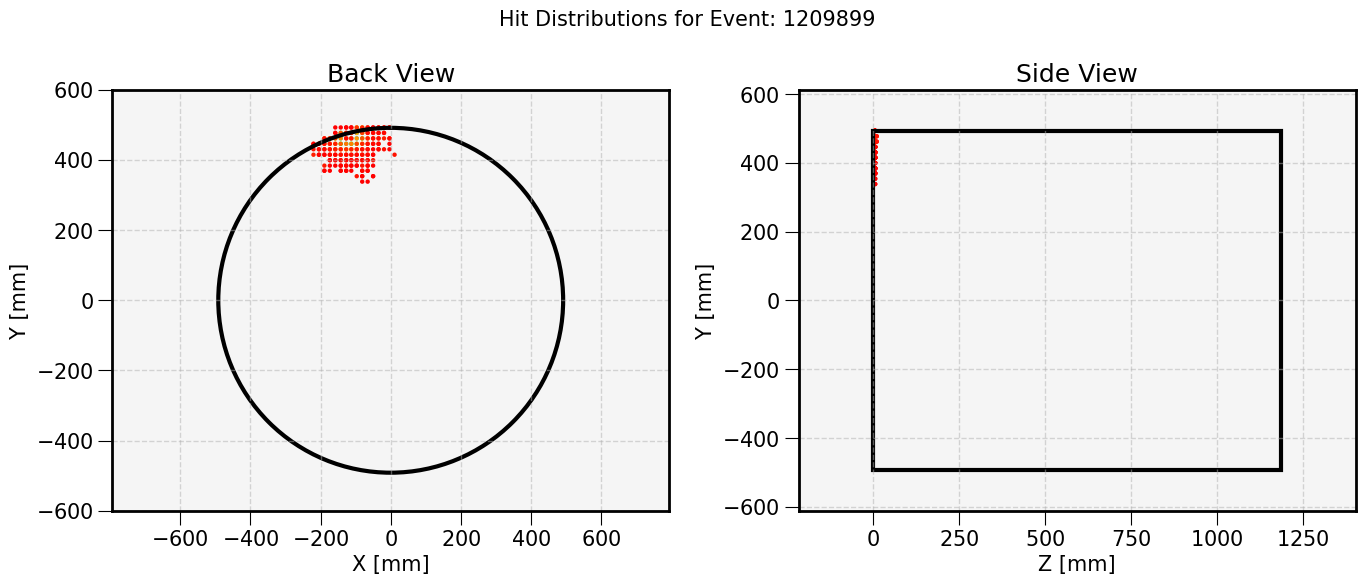

In [44]:
pt.event_display(test_hit_df, variable='E_hit_pe', event=np.random.choice(test_evt_electrons['event'].unique()))

## Execution

In [7]:
for run_id in RUNS_TO_ANALYZE:

    print(f"--- Analyzing Run {run_id} ---")

    # ----- Load Dataframes ----- #
    run_path = os.path.join(PROCESSED_DIR, f'processed_run_{run_id}_{VERSION_TAG}.h5')
    df_event = pd.read_hdf(run_path, key='Events')
    # df_hits  = pd.read_hdf(run_path, key='Hits')

    # ----- Minimum Q Value ----- #
    # print(f"  Min. Q = {df_hits['Q'].min():.4f} PE\n")

    # ----- Tagging ----- #
    # By particle type
    df_event = bf.tag_particles(df_event, size_threshold=SIZE_THRESHOLD, s1_energy_threshold=S1_ENERGY_THRESHOLD)
    # By detector region
    df_event = bf.tag_event_by_detector_region(df_event, z_cut_low=Z_LOW, z_cut_high=Z_UP, r_cut_high=R_UP)

    # ----- Trg2 Efficiency Cut ----- #
    # Convert from [pe] to [MeV] using HE scale
    df_event = bf.energy_pe_to_mev(df_event, slope=M_HE_SCALE, intercept=B_HE_SCALE, input_column='E_evt_pe', output_column='E_evt_mev')
    df_event = df_event[df_event['E_evt_mev'] >= TRG2_THRESHOLD].copy()
    EVT_COUNT_PER_RUN[run_id]['Trg2_Cut'] = int(df_event['event'].nunique())

    # ----- Inclusive Electrons ----- #
    df_event_electrons = df_event[df_event['particle'] == 'electron'].copy()
    EVT_COUNT_PER_RUN[run_id]['nElectrons'] = int(df_event_electrons['event'].nunique())

    # ----- Fiducial Electrons ----- #
    # nS2 = 1
    df_event_fiducial = df_event_electrons[df_event_electrons['nS2'] == 1].copy()
    EVT_COUNT_PER_RUN[run_id]['S2_Cut'] = int(df_event_fiducial['event'].nunique())
    # Fiducial region
    df_event_fiducial = df_event_fiducial[df_event_fiducial['region'] == 'fiducial'].copy()
    EVT_COUNT_PER_RUN[run_id]['nElectron_Fiducial'] = int(df_event_fiducial['event'].nunique())

print("Y ya, eso es todo, eso es todo ♥")

--- Analyzing Run 15299 ---
--- Analyzing Run 15318 ---
--- Analyzing Run 15319 ---
--- Analyzing Run 15330 ---
--- Analyzing Run 15331 ---
--- Analyzing Run 15332 ---
--- Analyzing Run 15462 ---
--- Analyzing Run 15472 ---
--- Analyzing Run 15478 ---
--- Analyzing Run 15479 ---
--- Analyzing Run 15484 ---
--- Analyzing Run 15485 ---
--- Analyzing Run 15486 ---
--- Analyzing Run 15487 ---
--- Analyzing Run 15488 ---
--- Analyzing Run 15489 ---
Y ya, eso es todo, eso es todo ♥


# Update Summary

In [8]:
# Convert dictionary to DataFrame
SELECT_SUMMARY_DF = pd.DataFrame.from_dict(EVT_COUNT_PER_RUN, orient='index')
SELECT_SUMMARY_DF.rename_axis("Run_ID", inplace=True)
SELECT_SUMMARY_DF.reset_index(inplace=True)
SELECT_SUMMARY_DF

,Run_ID,Trg2_Cut,nElectrons,S2_Cut,nElectron_Fiducial
0,15299,10360,2099,1514,248
1,15318,17006,3125,2701,411
2,15319,16449,2922,2480,370
3,15330,16407,2959,2389,371
4,15331,16065,2811,2281,349
5,15332,12781,2309,1878,278
6,15462,7567,1279,1061,139
7,15472,16482,2964,2508,356
8,15478,16691,3101,2650,399
9,15479,16746,2996,2520,404


In [35]:
#  Set 'Run_ID' as index in both dataframes
summary_with_index = SUMMARY_DF.set_index('Run_ID')
select_with_index  = SELECT_SUMMARY_DF.set_index('Run_ID')

# Update original summary with new selection counts
summary_with_index.update(select_with_index)

# Reset index to turn 'Run_ID' back into a column
UPDATED_SUMMARY_DF = summary_with_index.reset_index()
UPDATED_SUMMARY_DF

,Run_ID,Duration,Date_CV,Date_Err,OK,LOST,Reconstructed,Z_Positive,S1_Cut,Clean_Hits,Trg2_Cut,nElectrons,S2_Cut,nElectron_Fiducial
0,15299,60204,1.747095e+09,146.9611,18014,8929,17411,14809,11554,11553,10360.0,NaN,1514.0,248.0
1,15318,86706,1.747194e+09,172.3596,28735,1011,28043,24307,19081,19074,17006.0,NaN,2701.0,411.0
2,15319,85823,1.747281e+09,174.1556,27973,1008,27274,23734,18553,18544,16449.0,NaN,2480.0,370.0
3,15330,86462,1.747704e+09,171.3388,28157,1043,27508,23924,18485,18474,16407.0,NaN,2389.0,371.0
4,15331,85389,1.747791e+09,172.0570,27390,9966,26800,23300,18121,18115,16065.0,NaN,2281.0,349.0
5,15332,67758,1.747868e+09,154.4476,22010,8142,21445,18624,14434,14424,12781.0,NaN,1878.0,278.0
6,15462,39365,1.747948e+09,115.9820,12847,4532,12533,10878,8534,8532,7567.0,NaN,1061.0,139.0
7,15472,86563,1.748048e+09,175.7367,28505,1001,27372,23881,18707,18699,16482.0,NaN,2508.0,356.0
8,15478,86835,1.748210e+09,174.0899,28702,9999,27808,24299,18935,18924,16691.0,NaN,2650.0,399.0
9,15479,86876,1.748297e+09,174.5319,28713,1003,27966,24290,19014,19008,16746.0,NaN,2520.0,404.0


In [36]:
UPDATED_SUMMARY_DF.to_csv(SUMMARY_PATH)
print('Done! Summary updated in:', SUMMARY_PATH)

Done! Summary updated in: /lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/summary_rescale_p1.csv


# Rescale Factor for RAS: ON

In [41]:
# ----- Configuration ----- #
DATA_PERIOD = None                          # Options: None, 1, 2
DETECTOR_CONDITION = 'castle_closed_RAS'        # Options: None, 'castle_open', 'castle_closed', 'castle_closed_RAS', 'castle_pclosed', 'castle_pclosed_RAS'

In [42]:
selection_mask = pd.Series(True, index=RUNS_INFO_DF.index)

runs_in_summary = SUMMARY_DF['Run_ID'].unique()
print(f"→ Must be one of the {len(runs_in_summary)} runs in the summary.")
selection_mask &= RUNS_INFO_DF['run_number'].isin(runs_in_summary)

if DATA_PERIOD is not None:
    print(f"→ Period == {DATA_PERIOD}")
    # The '&=' operator is a shortcut for 'selection_mask = selection_mask & ...'
    selection_mask &= (RUNS_INFO_DF['period'] == DATA_PERIOD)

if DETECTOR_CONDITION is not None:
    print(f"→ Condition == '{DETECTOR_CONDITION}'")
    selection_mask &= (RUNS_INFO_DF['condition'] == DETECTOR_CONDITION)

RUNS_TO_ANALYZE = RUNS_INFO_DF.loc[selection_mask, 'run_number'].values
print(f"\nSelected {len(RUNS_TO_ANALYZE)} runs for analysis:\n{RUNS_TO_ANALYZE}")

→ Must be one of the 45 runs in the summary.
→ Condition == 'castle_closed_RAS'

Selected 29 runs for analysis:
[15520 15521 15527 15528 15535 15539 15540 15541 15542 15543 15544 15545
 15546 15547 15557 15632 15633 15634 15635 15636 15637 15639 15640 15642
 15643 15644 15647 15648 15649]


In [60]:
# Storage
Date_CV = [];  Date_Err = []
Rate_CV = [];  Rate_Err = []
Run_numbers = []

# ----- Run Loop ----- #
for run_id in RUNS_TO_ANALYZE:

    if run_id in [15632, 15648, 15649]:
        print(f"Don't want outliers like Run {run_id}, skipping...\n")
        continue

    print(f"Processing Run {run_id}")

    # Run information
    duration = SUMMARY_DF.loc[SUMMARY_DF['Run_ID'] == run_id, 'Duration'].values[0]
    OK_trg   = SUMMARY_DF.loc[SUMMARY_DF['Run_ID'] == run_id, 'OK'].values[0]
    LOST_trg = SUMMARY_DF.loc[SUMMARY_DF['Run_ID'] == run_id, 'LOST'].values[0]
    # DAQe efficiency + error
    DAQe_CV, DAQe_error = ff.efficiency(OK_trg, LOST_trg)
    Run_numbers.append(run_id)

    # Date + error for each run
    Date_CV.append(SUMMARY_DF.loc[SUMMARY_DF['Run_ID'] == run_id, 'Date_CV'].values[0])
    Date_Err.append(SUMMARY_DF.loc[SUMMARY_DF['Run_ID'] == run_id, 'Date_Err'].values[0])

    # Rate + error for each run
    fidu_evts = SUMMARY_DF.loc[SUMMARY_DF['Run_ID'] == run_id, 'nElectron_Fiducial'].values[0];    fidu_evts = int(fidu_evts)
    fidu_CV, fidu_var = scipy.stats.binom.stats(n=OK_trg, p=fidu_evts/OK_trg, moments='mv')
    print(f'  Fiducial Events = {fidu_CV:.2f}, Var = {fidu_var:.2f}, Duration = {duration} s, DAQe = {DAQe_CV:.4f} ± {DAQe_error:.4f}')

    # Fiducial rate + error
    rate_CV  = fidu_CV / (duration * DAQe_CV)
    rate_err = rate_CV * np.sqrt((np.sqrt(fidu_var) / fidu_CV)**2 + (DAQe_error / DAQe_CV)**2) 
    Rate_CV.append(rate_CV * 1e3)
    Rate_Err.append(rate_err * 1e3)
    print(f'  Rate = {rate_CV*1e3:.4f} ± {rate_err*1e3:.4f} mHz\n')

Processing Run 15520
  Fiducial Events = 290.00, Var = 287.00, Duration = 85170 s, DAQe = 0.7544 ± 0.0022
  Rate = 4.5132 ± 0.2640 mHz

Processing Run 15521
  Fiducial Events = 264.00, Var = 261.55, Duration = 85388 s, DAQe = 0.7628 ± 0.0022
  Rate = 4.0533 ± 0.2486 mHz

Processing Run 15527
  Fiducial Events = 211.00, Var = 209.11, Duration = 69725 s, DAQe = 0.7607 ± 0.0024
  Rate = 3.9781 ± 0.2729 mHz

Processing Run 15528
  Fiducial Events = 124.00, Var = 122.86, Duration = 41361 s, DAQe = 0.7525 ± 0.0032
  Rate = 3.9838 ± 0.3565 mHz

Processing Run 15535
  Fiducial Events = 294.00, Var = 291.00, Duration = 84904 s, DAQe = 0.7588 ± 0.0022
  Rate = 4.5636 ± 0.2651 mHz

Processing Run 15539
  Fiducial Events = 152.00, Var = 150.52, Duration = 56567 s, DAQe = 0.6197 ± 0.0031
  Rate = 4.3364 ± 0.3507 mHz

Processing Run 15540
  Fiducial Events = 214.00, Var = 211.97, Duration = 67663 s, DAQe = 0.7612 ± 0.0025
  Rate = 4.1548 ± 0.2830 mHz

Processing Run 15541
  Fiducial Events = 268.00,

In [61]:
def const_func(x, a):
    return ff.linear_func(x, 0, a)

# Storage
Period_info = {1: {}, 2: {}}

# Important date
P2_START = 1753178400       # Start of period 02

# ----- Linear Fit ----- #
# Preliminary
Date_CV  = np.array(Date_CV);        Date_Err = np.array(Date_Err)
Rate_CV  = np.array(Rate_CV);        Rate_Err = np.array(Rate_Err)

# Masking for each period
P1_time = (Date_CV < P2_START);      P2_time = (Date_CV >= P2_START)

for i, period in enumerate([P1_time, P2_time]):

    print(f'--- Period 0{i+1} ---')

    # Data selection
    x_data = Date_CV[period]
    y_data = Rate_CV[period]
    y_err  = Rate_Err[period]

    # Shifted time
    x_shift = (x_data - x_data[0]) / 3600   # In [hr] for numeric stability

    # Define the cost function + initial guess
    least_squares = LeastSquares(x_shift, y_data, y_err, const_func)
    init_guess = [y_data.min()]

    # print(f'\nFit 0{i+1}:\nInitial guess: {init_guess}')

    # Define the Minuit object
    m = Minuit(least_squares, *init_guess)

    # Minimization process of the cost function and error estimation
    m.migrad()
    m.hesse()

    # Results
    popt = m.values;  perr = m.errors
    print(f"Rate of Fiducial Background: ({popt[0]:.2f} ± {perr[0]:.2f}) mHz")
    Period_info[i+1]['Rate_CV']  = popt[0]
    Period_info[i+1]['Rate_Err'] = perr[0]

    # Reduced chi-square
    chi2 = m.fval
    ndof = len(x_shift) - m.nfit
    print(f"χ² / ndof = {chi2 / ndof:.4f}\n")
    Period_info[i+1]['Red_Chi2'] = chi2 / ndof

    # Fits
    x_fit = (x_shift * 3600) + x_data[0]  # In [s]
    y_fit = const_func(x_shift, *popt)
    Period_info[i+1]['x_fit'] = x_fit
    Period_info[i+1]['y_fit'] = y_fit

--- Period 01 ---
Rate of Fiducial Background: (4.32 ± 0.07) mHz
χ² / ndof = 0.9955

--- Period 02 ---
Rate of Fiducial Background: (3.83 ± 0.08) mHz
χ² / ndof = 0.4938



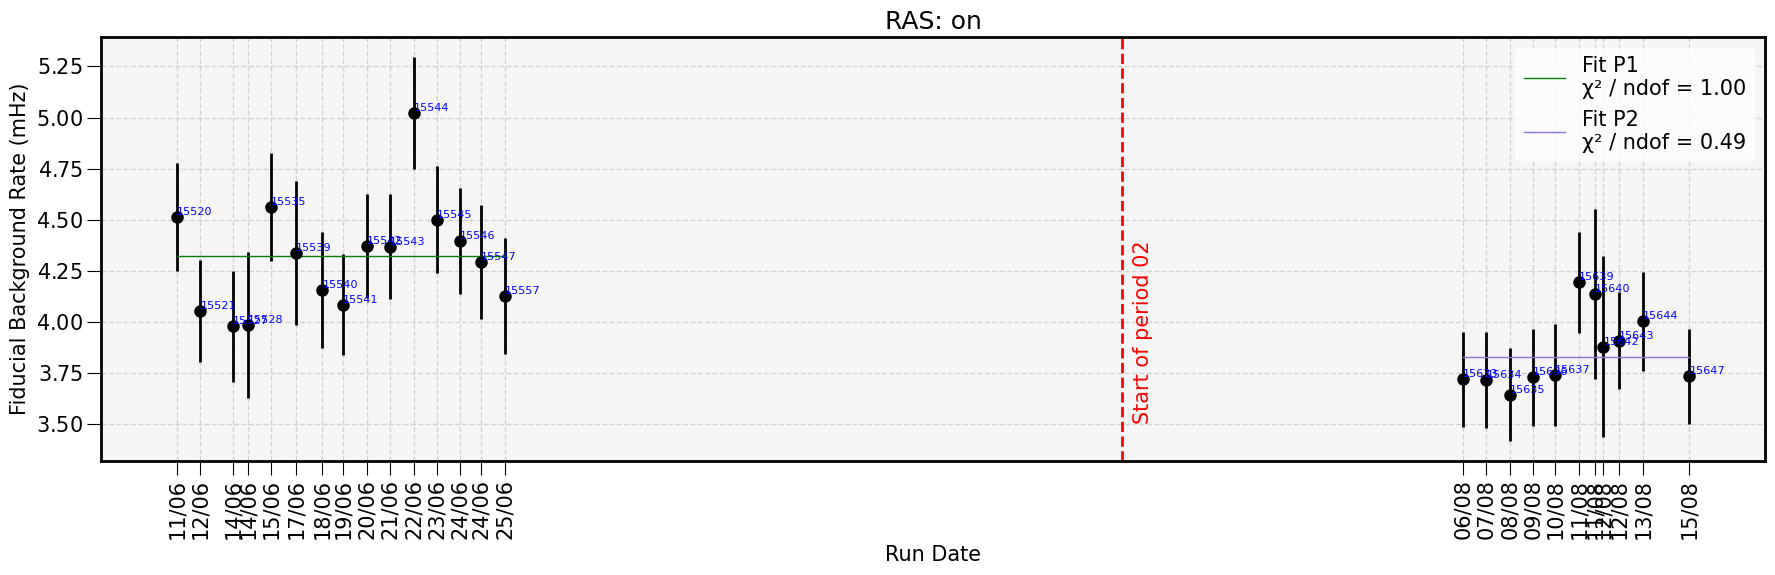

Ratio of Rates (P2 / P1): R = 0.8851 ± 0.0229


In [62]:
# ----- Plotting ----- #
plt.figure(figsize=(18, 6))

# Data
plt.errorbar(Date_CV, Rate_CV, xerr=Date_Err, yerr=Rate_Err, fmt='o', c='black', ecolor='black')
for x, y, run_id in zip(Date_CV, Rate_CV, Run_numbers):
    plt.text(x, y, str(run_id), fontsize=8, ha='left', va='bottom', color='blue')       # Run number near the point

# Fits
for i in [1, 2]:
    plt.plot(Period_info[i]['x_fit'], Period_info[i]['y_fit'], color=pt.hist_colors[4*i % len(pt.hist_colors)], ls='-', lw=1.0, label=f'Fit P{i}\nχ² / ndof = {Period_info[i]["Red_Chi2"]:.2f}')

# Important dates
plt.axvline(x=P2_START, color='red', ls='--')
plt.text(P2_START + 4e4, 3.5, 'Start of period 02', color='red', ha='left', va='bottom', rotation=90)

# Styling
x_labels = [crudo.epoch_converter(t, h=False) for t in Date_CV]        # Convert x-axis bin edges to readable time format
plt.xticks(Date_CV, x_labels, rotation=90, ha='center')
plt.xlabel('Run Date')
plt.ylabel('Fiducial Background Rate (mHz)')
plt.legend(loc='upper right')
plt.title('RAS: on')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.tight_layout()
plt.show()

# ---- Ratio of Rates (RAS = on) ---- #
R_CV  = Period_info[2]['Rate_CV'] / Period_info[1]['Rate_CV']
R_Err = R_CV * np.sqrt( (Period_info[1]['Rate_Err'] / Period_info[1]['Rate_CV'])**2 + (Period_info[2]['Rate_Err'] / Period_info[2]['Rate_CV'])**2 )
print(f'Ratio of Rates (P2 / P1): R = {R_CV:.4f} ± {R_Err:.4f}')